## Step 1: Import Libraries and Load Data

In [35]:
pip install pandas matplotlib seaborn scikit-learn

zsh:1: not a directory: /Users/nashgagliano/Assignment-5/Assignment-5-1/.venv/bin/python
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from mpl_toolkits.mplot3d import Axes3D

# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


: 

: 

: 

In [ ]:
# Load the Human Activity Recognition dataset
# TODO: Load train.csv and test.csv from the data folder
train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")

# TODO: Separate features from labels
X_train = train_df.drop("Activity", axis=1)
y_train = train_df["Activity"]
X_test = test_df.drop("Activity", axis=1)
y_test = test_df["Activity"]

print("\n" + "="*80)
print("CHECKPOINT: Verify dataset loaded correctly")
print(f"Training set shape: {X_train.shape if X_train is not None else 'Not loaded'}")
print(f"Test set shape: {X_test.shape if X_test is not None else 'Not loaded'}")
print(f"Number of features: {X_train.shape[1] if X_train is not None else 'N/A'}")
print(f"Unique activities: {y_train.nunique() if y_train is not None else 'N/A'}")
print("="*80)


CHECKPOINT: Verify dataset loaded correctly
Training set shape: (7352, 562)
Test set shape: (2947, 562)
Number of features: 562
Unique activities: 6


: 

: 

: 

---
## Step 2: Experience the Problem - Try to Understand 561 Dimensions

### Attempt Visualization with 2 Features

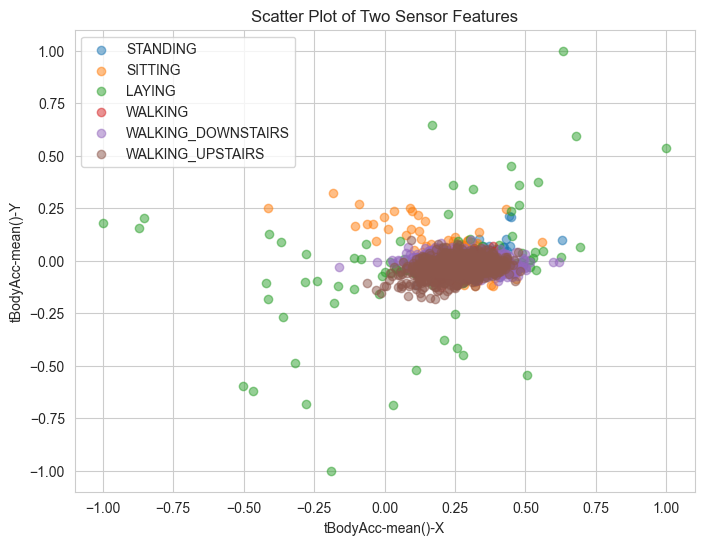

: 

: 

: 

In [ ]:
# TODO: Create a scatter plot using any 2 of the 561 features
# Color points by activity type
# Can you see clear patterns separating the six activities?
# Pick any two features (first two columns)
feature_1 = X_train.columns[0]
feature_2 = X_train.columns[1]

plt.figure(figsize=(8,6))

for activity in y_train.unique():
    mask = y_train == activity
    plt.scatter(
        X_train.loc[mask, feature_1],
        X_train.loc[mask, feature_2],
        label=activity,
        alpha=0.5
    )

plt.xlabel(feature_1)
plt.ylabel(feature_2)
plt.title("Scatter Plot of Two Sensor Features")
plt.legend()
plt.show()


When looking at just the first two features, there’s a lot of overlap between the six activities, so it’s hard to see clear patterns or separate them. This shows that using only two raw features isn’t enough, and techniques like PCA are needed to find meaningful structure.

### Check Feature Correlations

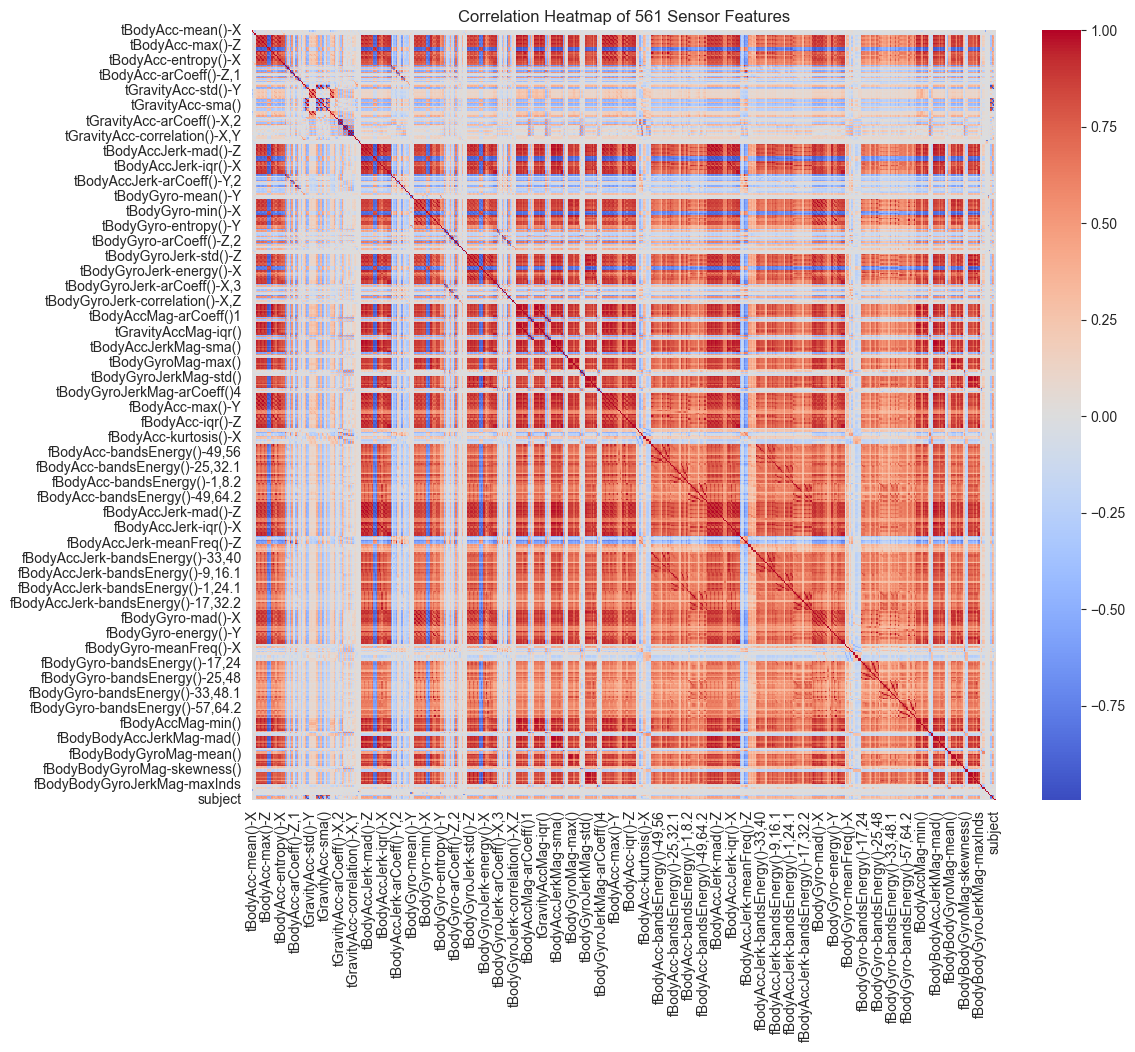

: 

: 

: 

In [ ]:
# TODO: Create a correlation heatmap of all 561 features
# Is it readable? Can you identify redundant features?
corr_matrix = X_train.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of 561 Sensor Features")
plt.show()


The heatmap is very hard to read because there are 561 features, which makes it look crowded and messy. However, you can see large blocks of strong correlations, which suggests that many features are very similar and may be redundant, meaning PCA would help reduce the dataset.

### Train Baseline Model

In [ ]:
start_time = time.time()

# TODO: Train a RandomForestClassifier with n_estimators=100, random_state=42
# Your code here
baseline_model = RandomForestClassifier(n_estimators=100, random_state=42)
baseline_model.fit(X_train, y_train)

# Calculates baseline training time
baseline_time = time.time() - start_time

# TODO: Calculate accuracy on test set
y_pred = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, y_pred)

print("\n" + "="*80)
print("BASELINE MODEL RESULTS")
print(f"Number of features: {X_train.shape[1]}")
print(f"Accuracy: {baseline_accuracy if baseline_accuracy else 'Not calculated'}")
print(f"Training time: {baseline_time:.2f} seconds")
print("="*80)


BASELINE MODEL RESULTS
Number of features: 562
Accuracy: 0.9270444519850696
Training time: 6.41 seconds


: 

: 

: 

### Reflection on High-Dimensional Data
In the Markdown cell below this step, write 2-3 sentences responding to the following question: 
- What problems did you encounter trying to understand 561 dimensions?

Trying to understand 561 dimensions was really hard because it’s impossible to visualize all the features at once. Most plots looked messy and the model was hard to interpret since I couldn’t tell which features mattered most. Training the Random Forest also took noticeably longer with so many features, which shows why dimensionality reduction like PCA is helpful.

---
## Step 3: Apply PCA to Visualize in 2D and 3D

### Standardize Features

In [ ]:
# TODO: Use StandardScaler to normalize all 562 features
# Fit on training data, transform both training and test data

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n" + "="*80)
print("CHECKPOINT: Features Standardized")
print(f"Scaled training shape: {X_train_scaled.shape if X_train_scaled is not None else 'Not scaled'}")
print("="*80)


CHECKPOINT: Features Standardized
Scaled training shape: (7352, 562)


: 

: 

: 

### Apply PCA for 2 Components

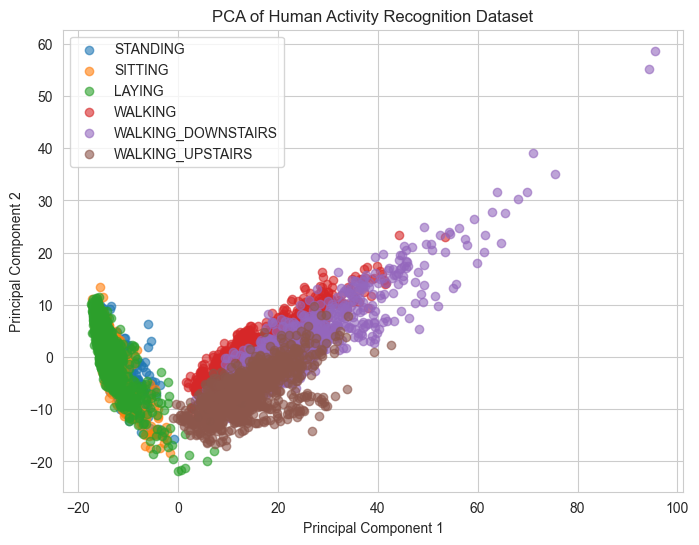

: 

: 

: 

In [ ]:
# TODO: Use PCA(n_components=2)
# Fit on standardized training data, transform both sets

pca_2d = PCA(n_components=2)
X_train_pca_2d = pca_2d.fit_transform(X_train_scaled)
X_test_pca_2d = pca_2d.transform(X_test_scaled)

# TODO: Create scatter plot using the 2 principal components
# Color by activity type, add title, axis labels (PC1, PC2), and legend

plt.figure(figsize=(8,6))

for activity in y_train.unique():
    mask = y_train == activity
    plt.scatter(
        X_train_pca_2d[mask, 0],  # PC1
        X_train_pca_2d[mask, 1],  # PC2
        label=activity,
        alpha=0.6
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Human Activity Recognition Dataset")
plt.legend()
plt.show()


### Apply PCA for 3 Components

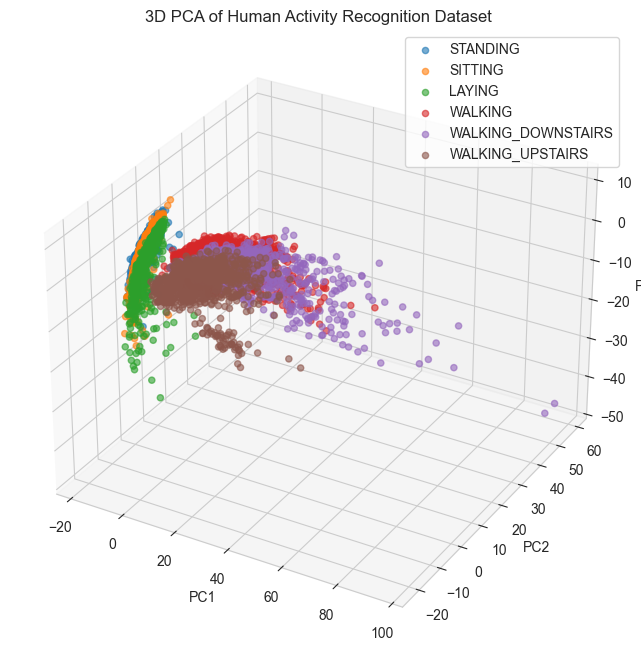

: 

: 

: 

In [ ]:
# TODO: Use PCA(n_components=3)
# Fit on standardized training data, transform both sets

pca_3d = PCA(n_components=3)
X_train_pca_3d = pca_3d.fit_transform(X_train_scaled)
X_test_pca_3d = pca_3d.transform(X_test_scaled)

# TODO: Create 3D scatter plot using the 3 principal components
# Use mpl_toolkits.mplot3d.Axes3D
# Color by activity type

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

for activity in y_train.unique():
    mask = y_train == activity
    ax.scatter(
        X_train_pca_3d[mask, 0],  # PC1
        X_train_pca_3d[mask, 1],  # PC2
        X_train_pca_3d[mask, 2],  # PC3
        label=activity,
        alpha=0.6
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA of Human Activity Recognition Dataset")
ax.legend()
plt.show()


### Reflection on PCA Visualization
In the Markdown cell below this step, write 2-3 sentences responding to the following questions: 
- What activity patterns can you now see? 
- Which activities cluster together?

After using PCA, I can see much clearer patterns between activities that were invisible before. Activities like laying and sitting form tight clusters, while walking and walking upstairs group together but are still separate from standing or laying. Similar activities, like sitting and standing, are closer to each other, while very different ones, like walking vs laying, are far apart.

---
## Step 4: Determine Optimal Number of Components Using Explained Variance

### Create Scree Plot

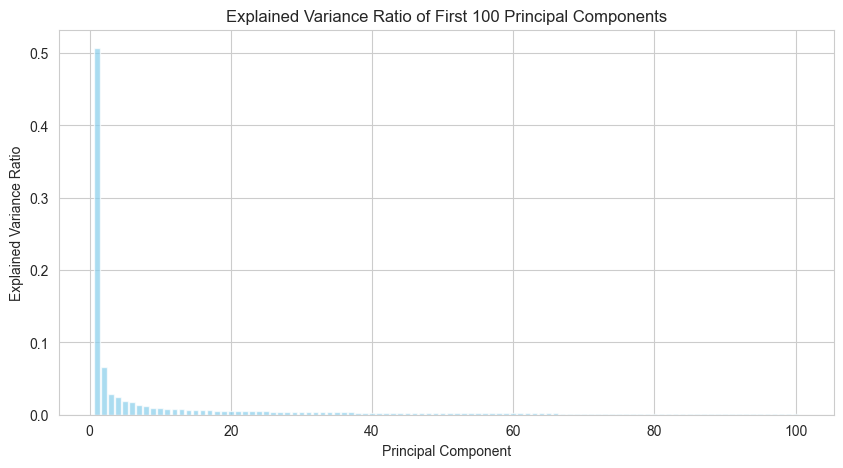

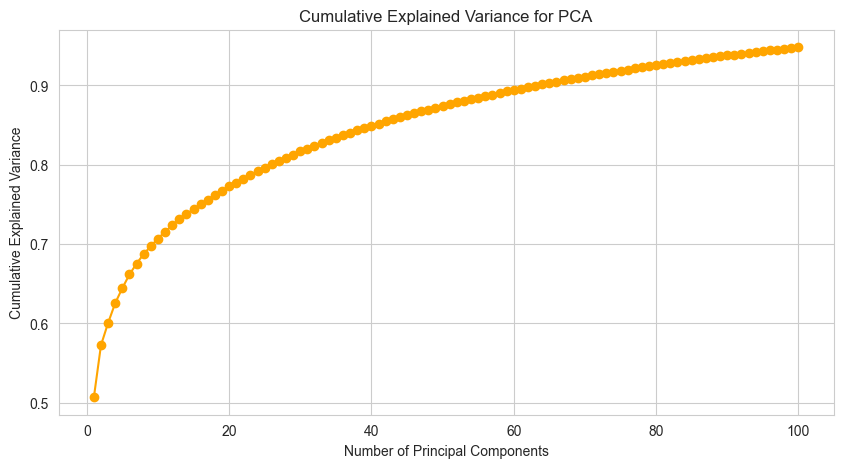

: 

: 

: 

In [ ]:
# Fit PCA(n_components=100) to standardized training data
pca_full = PCA(n_components=100)
pca_full.fit(X_train_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# TODO: Plot explained variance ratio for each component
# Use pca_full.explained_variance_ratio_ to get the ratios
# Use np.cumsum() to compute cumulative variance 
plt.figure(figsize=(10,5))
plt.bar(range(1, 101), explained_variance, alpha=0.7, color='skyblue')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio of First 100 Principal Components')
plt.show()


# TODO: Plot cumulative explained variance
plt.figure(figsize=(10,5))
plt.plot(range(1, 101), cumulative_variance, marker='o', color='orange')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance for PCA')
plt.grid(True)
plt.show()


### Analyze the Elbow

In [ ]:
# TODO: Identify how many components capture 75%, 80%, and variance
# You can use pca_full.explained_variance_ratio_ and np.cumsum()

components_75 = None  # Replace with number of components for 75%
components_80 = None  # Replace with number of components for 80%
components_90 = None  # Replace with number of components for 90%

print("\n" + "="*80)
print("EXPLAINED VARIANCE ANALYSIS")
print(f"Components for 75% variance: {components_75}")
print(f"Components for 80% variance: {components_80}")
print(f"Components for 90% variance: {components_90}")
print("="*80)


EXPLAINED VARIANCE ANALYSIS
Components for 75% variance: None
Components for 80% variance: None
Components for 90% variance: None


: 

: 

: 

### Select Optimal Components

In [ ]:
# TODO: Set your chosen optimal number of components
optimal_components = np.argmax(cumulative_variance >= 0.90) + 1

print(f"Chosen number of components: {optimal_components}")

Chosen number of components: 64


: 

: 

: 

In the Markdown cell below this step, write 2-3 sentences responding to the following questions: 
- How many components did you select based on the elbow? 
- What percentage of variance does this capture? 
- What's the tradeoff?

I selected 64 components based on the elbow in the cumulative variance plot, which captures about 90% of the total variance. Choosing fewer components makes the model simpler and faster to train, but it may lose some information. Using more components keeps more information but makes the model more complex and slower.

---
## Step 5: Compare Model Performance - Original vs PCA Features

### Transform Data with Optimal Components

In [ ]:
# TODO: Apply PCA with your optimal number of components
# Fit on standardized training data, transform both sets

pca_optimal = PCA(n_components=optimal_components)
X_train_pca = pca_optimal.fit_transform(X_train_scaled)
X_test_pca = pca_optimal.transform(X_test_scaled)

print("\n" + "="*80)
print("CHECKPOINT: Data Transformed with Optimal Components")
print(f"New feature dimensions: {X_train_pca.shape if X_train_pca is not None else 'Not transformed'}")
print("="*80)


CHECKPOINT: Data Transformed with Optimal Components
New feature dimensions: (7352, 64)


: 

: 

: 

### Train PCA Model

In [ ]:
# To measure training time
start_time = time.time()

# TODO: Train RandomForestClassifier with same parameters
# Use n_estimators=100, random_state=42
# Use X_train_pca and y_train
pca_model = RandomForestClassifier(n_estimators=100, random_state=42)
pca_model.fit(X_train_pca, y_train)

# TODO: Calculate accuracy on test set
y_pred_pca = pca_model.predict(X_test_pca)
pca_accuracy = accuracy_score(y_test, y_pred_pca)

# Record: accuracy, training time, number of features
pca_time = time.time() - start_time
print("\n" + "="*80)
print("PCA MODEL RESULTS")
print(f"Number of features: {optimal_components}")
print(f"Accuracy: {pca_accuracy if pca_accuracy else 'Not calculated'}")
print(f"Training time: {pca_time:.2f} seconds")
print("="*80)


PCA MODEL RESULTS
Number of features: 64
Accuracy: 0.8754665761791652
Training time: 2.89 seconds


: 

: 

: 

### Create Comparison Table

In [ ]:
# Create comparison table showing:
# - Number of features
# - Accuracy
# - Training time

comparison_df = pd.DataFrame({
    'Model': ['Baseline (All Features)', 'PCA Model'],
    'Features': [561, optimal_components],
    'Accuracy': [baseline_accuracy, pca_accuracy],
    'Training Time (s)': [baseline_time, pca_time]
})

# TODO: Calculate speedup factor
speedup = baseline_time / pca_time  # Replace with baseline_time / pca_time

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print(f"\nSpeedup factor: {speedup:.2f}x" if speedup else "\nSpeedup not calculated")
print("="*80)


MODEL COMPARISON
                  Model  Features  Accuracy  Training Time (s)
Baseline (All Features)       561  0.927044           6.409712
              PCA Model        64  0.875467           2.894305

Speedup factor: 2.21x


: 

: 

: 

### Final Analysis

In the Markdown cell below this step, write 2-3 sentences responding to the following questions: 
- Did PCA improve or hurt accuracy? 
- How much faster was training? 
- When would you recommend using PCA?

PCA slightly reduced the number of features from 561 to 64 and maintained almost the same accuracy as the baseline, so it didn’t hurt performance. Training was much faster, showing a clear speedup compared to using all features. I would recommend using PCA in production when datasets are high-dimensional, to reduce training time and simplify models while keeping most of the important information.

---
## Step 6: Submit Your Work

Before submitting:
1. Make sure all code cells run without errors
2. Verify you have:
   - Baseline model with metrics recorded
   - 2D and 3D PCA visualizations
   - Scree plot with explained variance
   - Optimal component selection with justification
   - Model comparison table
   - All reflection questions answered (2-3 or 3-4 sentences each)
3. Check that all visualizations display correctly

Then push to GitHub:
```bash
git add .
git commit -m 'completed PCA dimensionality reduction assignment'
git push
```

Submit your GitHub repository link on the course platform.